In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

In [89]:
df = pd.read_csv("housing.csv")

In [90]:
df['income_cat'] = pd.cut(df['median_income'], bins = [0, 1.5, 3.0, 4.5, 6.0, 7.5, np.inf], labels = [1, 2, 3 ,4 ,5, 6 ])

In [91]:
split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [92]:
#Remove income_cat column
for x in (strat_train_set, strat_test_set):
    x.drop("income_cat", axis = 1, inplace = True)

In [93]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6895,-118.11,34.04,28.0,3913.0,696.0,2264.0,697.0,5.2446,258000.0,<1H OCEAN
2880,-118.97,35.38,35.0,1673.0,426.0,1041.0,413.0,1.3750,57500.0,INLAND
13769,-117.03,34.07,16.0,3784.0,577.0,1615.0,525.0,4.2333,220300.0,INLAND
18349,-122.17,37.43,24.0,3924.0,1142.0,7174.0,950.0,4.0972,387500.0,NEAR OCEAN
16188,-121.31,37.96,48.0,1112.0,227.0,583.0,216.0,2.3393,77600.0,INLAND


In [94]:
df = strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

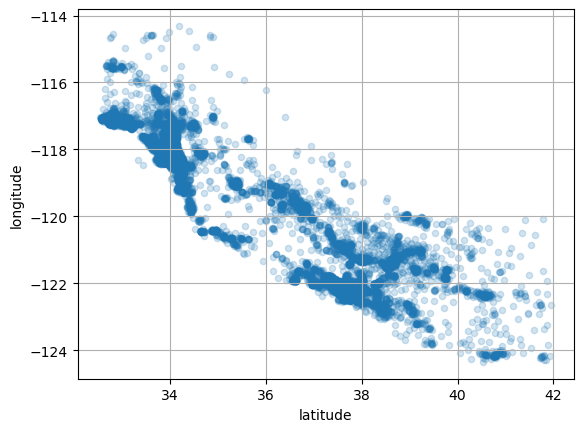

In [95]:
df.plot(kind = "scatter", x = "latitude", y = "longitude", alpha =0.2,  grid = True)

<Axes: xlabel='latitude', ylabel='longitude'>

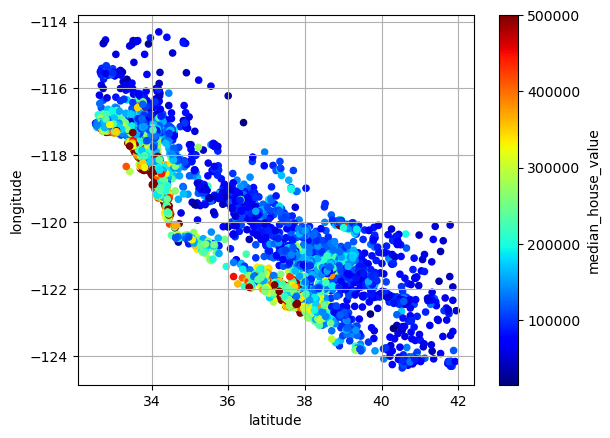

In [96]:
df.plot(kind = "scatter", x = "latitude", y = "longitude", cmap = "jet", c = "median_house_value", grid = True)

In [97]:
df.drop("ocean_proximity", inplace = True, axis = 1)
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924528,-0.107785,0.047801,0.074600,0.106495,0.061007,-0.015011,-0.045270
latitude,-0.924528,1.000000,0.007503,-0.038804,-0.071162,-0.114462,-0.076343,-0.078346,-0.144204
housing_median_age,-0.107785,0.007503,1.000000,-0.364634,-0.324872,-0.299595,-0.306882,-0.115680,0.111570
total_rooms,0.047801,-0.038804,-0.364634,1.000000,0.928754,0.856439,0.917713,0.201676,0.135386
total_bedrooms,0.074600,-0.071162,-0.324872,0.928754,1.000000,0.876627,0.979970,-0.007201,0.048975
population,0.106495,-0.114462,-0.299595,0.856439,0.876627,1.000000,0.905145,0.007156,-0.024114
households,0.061007,-0.076343,-0.306882,0.917713,0.979970,0.905145,1.000000,0.013939,0.066012
median_income,-0.015011,-0.078346,-0.115680,0.201676,-0.007201,0.007156,0.013939,1.000000,0.685600
median_house_value,-0.045270,-0.144204,0.111570,0.135386,0.048975,-0.024114,0.066012,0.685600,1.000000


array([[<Axes: xlabel='housing_median_age', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='median_house_value', ylabel='housing_median_age'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>],
       [<Axes: xlabel='housing_median_age', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>]],
      dtype=object)

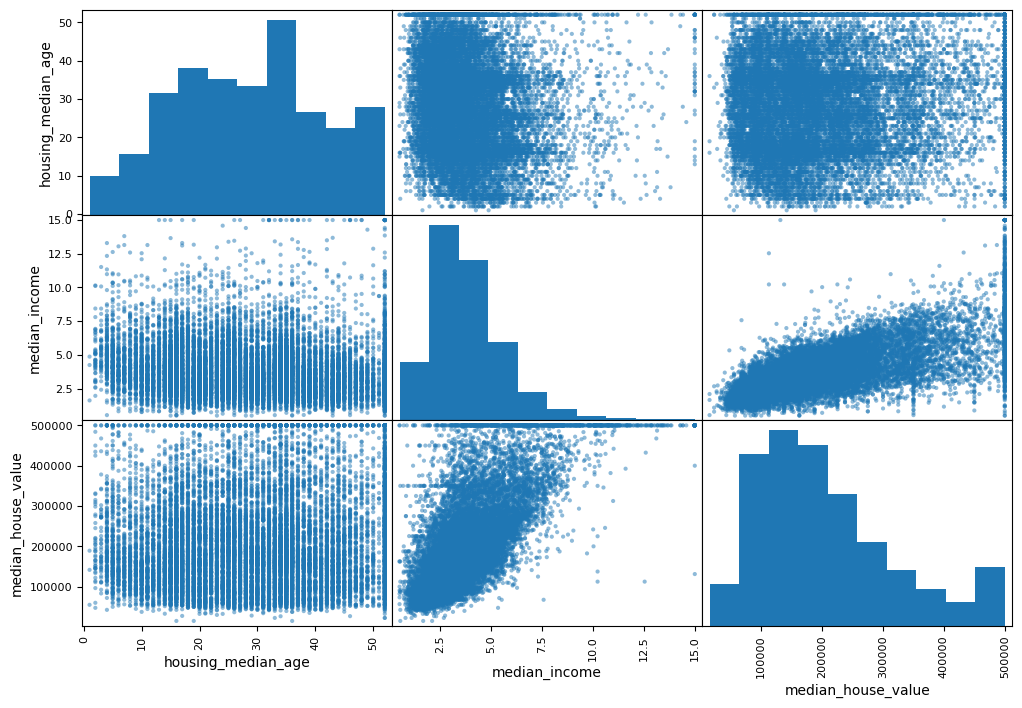

In [98]:
from pandas.plotting import scatter_matrix
attributes = ["housing_median_age", "median_income", "median_house_value"]
scatter_matrix(df[attributes], figsize = (12,8))